# Real Estate Sales 2001 - 2020 Analysis

##### https://www.kaggle.com/datasets/derrekdevon/real-estate-sales-2001-2020

###  Import Library dan Dataset

- pandas untuk manipulasi dan analisis data
- numpy untuk komputasi numerik
- matplotlib.pyplot untuk uat visualisasi data
- seaborn untuk membuat visualisasi data yang lebih menarik dan informatif
- sklearn.preprocessing untuk menskalakan fitur data ke rentang tertentu 
- sklearn.cluster untuk melakukan clustering data menggunakan algoritma K-Means.
- sklearn.impute untuk menangani nilai yang hilang dalam dataset dengan strategi imputasi sederhana (misalnya, mengganti nilai yang hilang dengan rata-rata atau median).

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

data = pd.read_csv('/home/fzlfade/Documents/Datasets/Real estate/Real_Estate_Sales_2001-2020_GL.csv')


print(data.head())


   Serial Number  List Year Date Recorded     Town                Address  \
0        2020348       2020     9/13/2021  Ansonia        230 WAKELEE AVE   
1          20002       2020     10/2/2020  Ashford        390 TURNPIKE RD   
2         200212       2020      3/9/2021     Avon       5 CHESTNUT DRIVE   
3         200243       2020     4/13/2021     Avon  111 NORTHINGTON DRIVE   
4         200377       2020      7/2/2021     Avon     70 FAR HILLS DRIVE   

   Assessed Value  Sale Amount  Sales Ratio Property Type Residential Type  \
0          150500     325000.0       0.4630    Commercial              Nan   
1          253000     430000.0       0.5883   Residential    Single Family   
2          130400     179900.0       0.7248   Residential            Condo   
3          619290     890000.0       0.6958   Residential    Single Family   
4          862330    1447500.0       0.5957   Residential    Single Family   

   Years until sold  
0                 1  
1                 0  
2 

### Cleaning Data

/tmp/ipykernel_7779/258499972.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Residential Type'].fillna('Unknown', inplace=True)


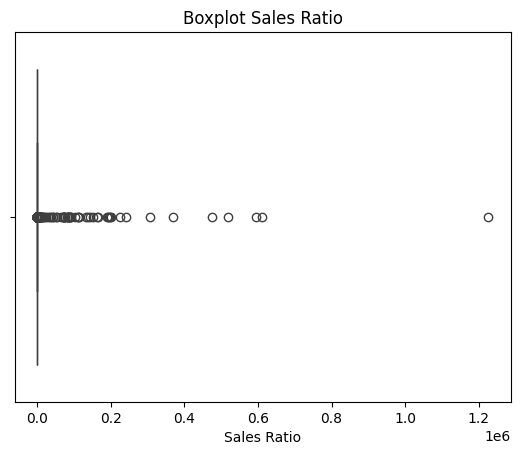

<class 'pandas.core.frame.DataFrame'>
Index: 936781 entries, 0 to 997212
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Serial Number     936781 non-null  int64         
 1   List Year         936781 non-null  int64         
 2   Date Recorded     936781 non-null  datetime64[ns]
 3   Town              936781 non-null  object        
 4   Address           936781 non-null  object        
 5   Assessed Value    936781 non-null  int64         
 6   Sale Amount       936781 non-null  float64       
 7   Sales Ratio       936781 non-null  float64       
 8   Property Type     936781 non-null  object        
 9   Residential Type  936781 non-null  object        
 10  Years until sold  936781 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 85.8+ MB
None


In [36]:
data['Residential Type'].fillna('Unknown', inplace=True)

data['Date Recorded'] = pd.to_datetime(data['Date Recorded'], format='%m/%d/%Y')

sns.boxplot(x=data['Sales Ratio'])
plt.title('Boxplot Sales Ratio')
plt.show()

data = data[data['Sales Ratio'] < 1.5]

print(data.info())


### Normalisasi Data Numerik

In [37]:
numerical_cols = ['Assessed Value', 'Sale Amount', 'Sales Ratio', 'Years until sold']

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[numerical_cols])

data_scaled = pd.DataFrame(data_scaled, columns=numerical_cols)
print(data_scaled.head())


   Assessed Value  Sale Amount  Sales Ratio  Years until sold
0        0.001053     0.000065     0.308687          0.904762
1        0.001771     0.000086     0.392226          0.857143
2        0.000913     0.000036     0.483232          0.904762
3        0.004335     0.000178     0.463898          0.904762
4        0.006036     0.000289     0.397160          0.904762


### Clustering Menggunakan K-Means



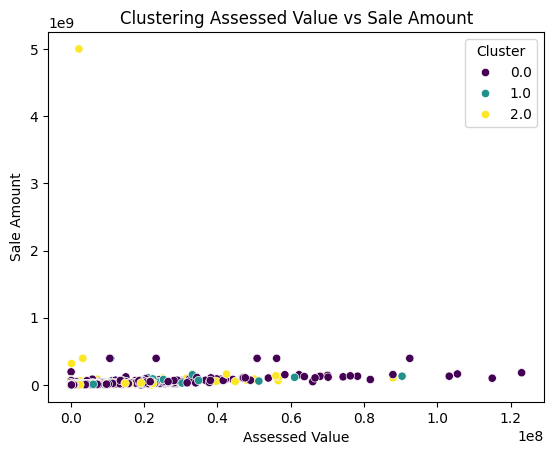

In [38]:
kmeans = KMeans(n_clusters=3, random_state=42)

data_scaled['Cluster'] = kmeans.fit_predict(data_scaled)

data['Cluster'] = data_scaled['Cluster']

sns.scatterplot(data=data, x='Assessed Value', y='Sale Amount', hue='Cluster', palette='viridis')
plt.title('Clustering Assessed Value vs Sale Amount')
plt.show()


#### Karena ada alomani data, jadi saya melakukan Normalisasi lagi melakukan identifikasi Outlier 

In [39]:
print(data['Sale Amount'].max())

extreme_outliers = data[data['Sale Amount'] > 1e9]
print(extreme_outliers)


5000000000.0
       Serial Number  List Year Date Recorded        Town           Address  \
59835       20200091       2020    2021-08-19  Willington  456 TOLLAND TPKE   

       Assessed Value   Sale Amount  Sales Ratio Property Type  \
59835         2238530  5.000000e+09     0.000448    Apartments   

      Residential Type  Years until sold  Cluster  
59835              Nan                 1      2.0  


##### Hapus Outlier


In [40]:
data = data[data['Sale Amount'] <= 1e9]


##### Winsorization (Batasi Nilai Outlier)

In [41]:
data['Sale Amount'] = np.clip(data['Sale Amount'], None, 1e9)


##### Transformasi Logaritmik

In [42]:
data['Sale Amount'] = np.log1p(data['Sale Amount'])


##### Visualisasi Ulang


/home/fzlfade/big-data/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


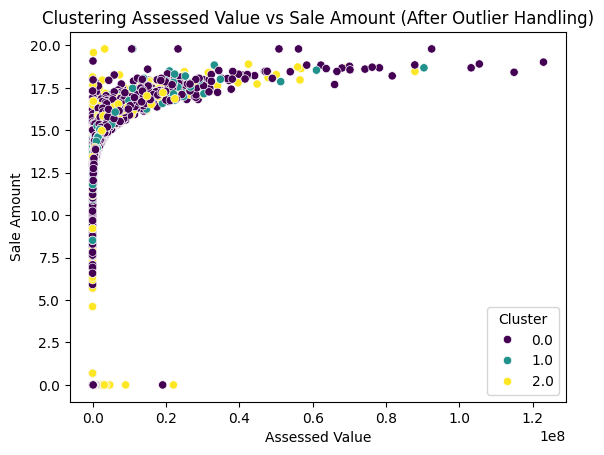

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=data, x='Assessed Value', y='Sale Amount', hue='Cluster', palette='viridis')
plt.title('Clustering Assessed Value vs Sale Amount (After Outlier Handling)')
plt.show()


##### Visualisasi Distribusi dan Korelasi

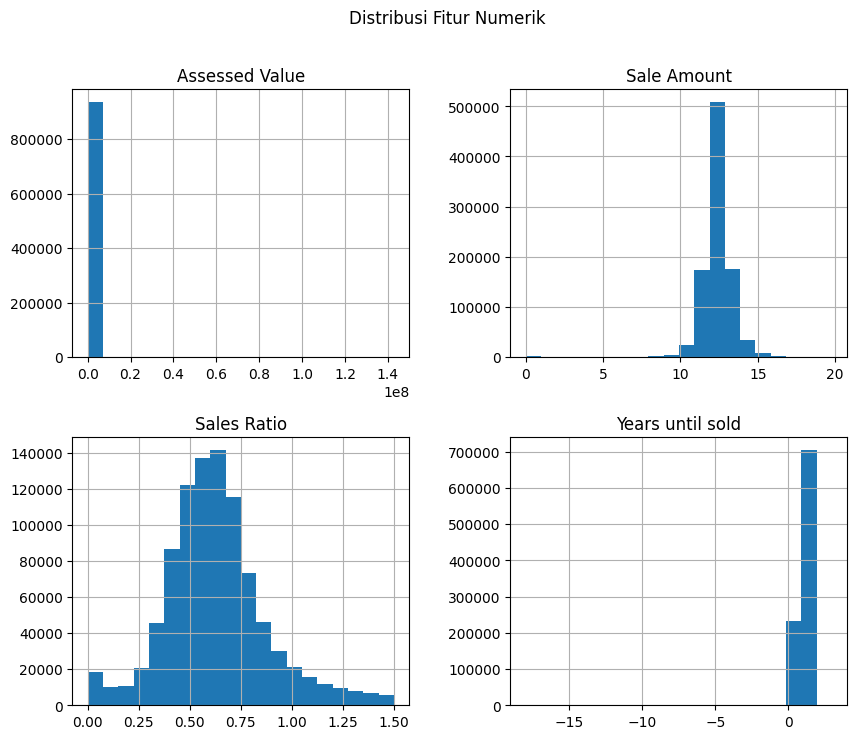

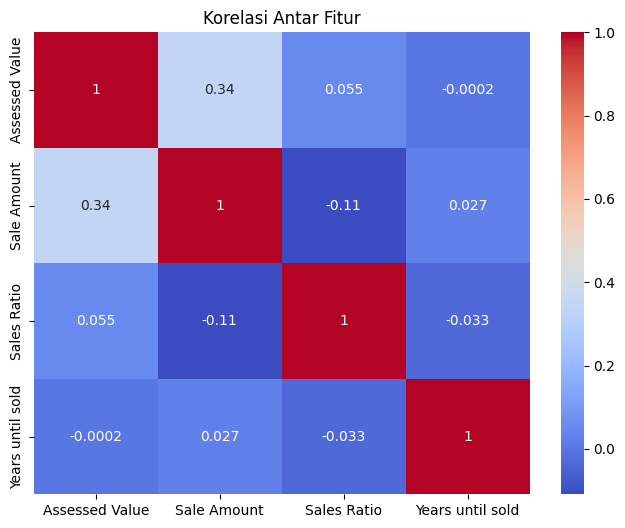

In [44]:
data[numerical_cols].hist(figsize=(10, 8), bins=20)
plt.suptitle('Distribusi Fitur Numerik')
plt.show()
    
plt.figure(figsize=(8, 6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur')
plt.show()
